In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# 1. Load Data
file_path = 'pi_status_log.csv'
df = pd.read_csv(file_path)

In [3]:
# 2. Data Preprocessing
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [4]:
# ฟังก์ชันถอดรหัส Hex สำหรับ Voltage/Throttling
def analyze_throttled(hex_val):
    val = int(hex_val, 16)
    under_volt_now = bool(val & 0x1)
    under_volt_occurred = bool(val & 0x10000)
    throttling_now = bool(val & 0x2)
    return under_volt_now, under_volt_occurred, throttling_now


In [5]:
# เพิ่มคอลัมน์วิเคราะห์ความเสี่ยง
df['UV_Now'], df['UV_Past'], df['Throttling'] = zip(*df['Voltage_Hex'].apply(analyze_throttled))

In [9]:
# 3. Summary Statistics
print("--- Pi Health Summary Report ---")
print(f"Period: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"Average Temperature: {df['Temperature_C'].mean():.2f} C")
print(f"Max Temperature: {df['Temperature_C'].max():.2f} C")
print(f"Voltage Drop Events: {df['UV_Past'].sum()} times")
print(f"Total Print Jobs Processed: {df['Queue_Jobs'].sum()} jobs")
print("--------------------------------")

--- Pi Health Summary Report ---
Period: 2026-04-17 12:30:01 to 2026-04-17 13:35:01
Average Temperature: 56.34 C
Max Temperature: 56.90 C
Voltage Drop Events: 0 times
Total Print Jobs Processed: 0 jobs
--------------------------------


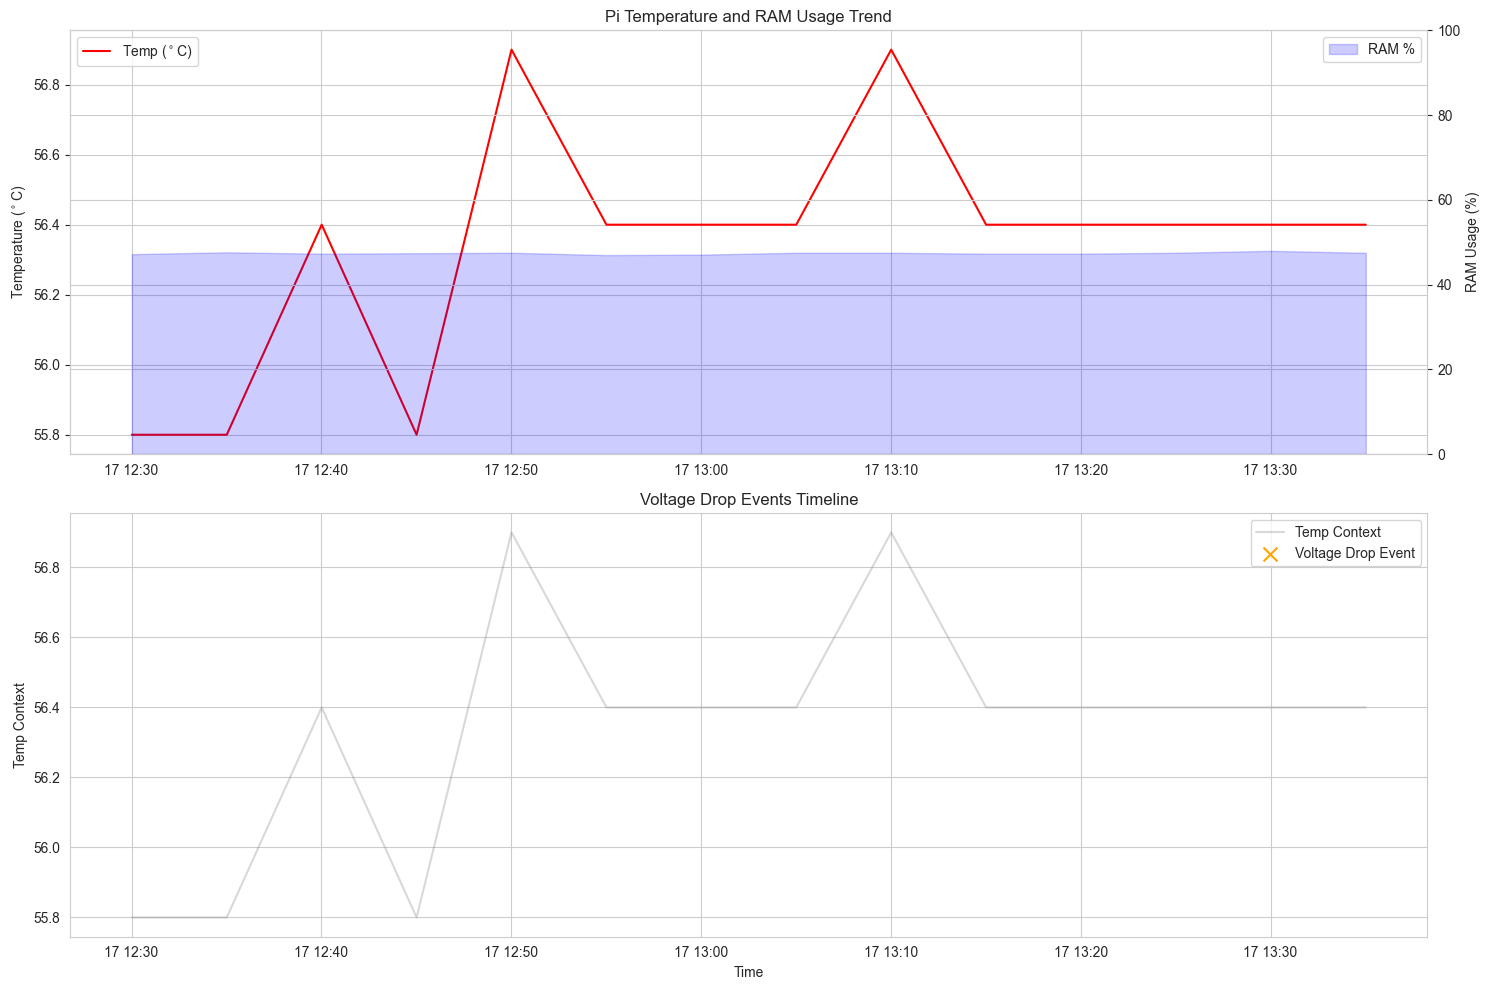

In [7]:
# 4. Visualization
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

# กราฟที่ 1: Temperature & RAM Usage Over Time
plt.subplot(2, 1, 1)
plt.plot(df['Timestamp'], df['Temperature_C'], color='red', label='Temp ($^\circ$C)')
plt.ylabel('Temperature ($^\circ$C)')
plt.title('Pi Temperature and RAM Usage Trend')
plt.legend(loc='upper left')

ax2 = plt.twinx()
ax2.fill_between(df['Timestamp'], df['RAM_Usage_Percent'], color='blue', alpha=0.2, label='RAM %')
ax2.set_ylabel('RAM Usage (%)')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right')

# กราฟที่ 2: Voltage Drop Events (Visualized as Scatter)
plt.subplot(2, 1, 2)
uv_events = df[df['UV_Past'] == True]
plt.plot(df['Timestamp'], df['Temperature_C'], color='gray', alpha=0.3, label='Temp Context')
plt.scatter(uv_events['Timestamp'], [df['Temperature_C'].mean()]*len(uv_events), 
            color='orange', label='Voltage Drop Event', marker='x', s=100)
plt.title('Voltage Drop Events Timeline')
plt.xlabel('Time')
plt.ylabel('Temp Context')
plt.legend()

plt.tight_layout()
plt.show()